# Quickstart: UCSB CHC CHIRPS analysis, preliminary - dynamical.org Icechunk Zarr

CHIRPS v3 from the UCSB Climate Hazards Center provides daily precipitation over global land from 60°S to 60°N on a 0.05° grid.

This preliminary product begins in 2025 and is transformed into an analysis-ready Zarr store by [dynamical.org](https://dynamical.org).

Dataset documentation: https://dynamical.org/catalog/ucsb-chc-chirps-analysis-preliminary/

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install dynamical-catalog matplotlib

In [2]:
import os

import dynamical_catalog

os.environ["DYNAMICAL_STAC_CATALOG_URL"] = "https://stac-staging.dynamical.org/catalog.json"
ds = dynamical_catalog.open("ucsb-chc-chirps-analysis-preliminary", chunks=None)
ds

<xarray.Dataset> Size: 43GB
Dimensions:                (time: 618, latitude: 2400, longitude: 7200)
Coordinates:
  * time                   (time) datetime64[ns] 5kB 2025-01-01 ... 2026-09-10
  * latitude               (latitude) float64 19kB 59.98 59.93 ... -59.93 -59.98
  * longitude              (longitude) float64 58kB -180.0 -179.9 ... 180.0
    spatial_ref            int64 8B ...
Data variables:
    precipitation_surface  (time, latitude, longitude) float32 43GB ...
Attributes:
    dataset_id:          ucsb-chc-chirps-analysis-preliminary
    dataset_version:     0.1.0
    name:                UCSB CHC CHIRPS analysis, preliminary
    description:         Daily precipitation from the Climate Hazards Center ...
    attribution:         UCSB Climate Hazards Center CHIRPS version 3.0 data ...
    license:             CC-BY-4.0
    spatial_domain:      Global land, 60 degrees north to 60 degrees south
    spatial_resolution:  0.05 degrees (~5km)
    time_domain:         2025-01-01 00:00:00 UTC to Present
    time_resolution:     1 day

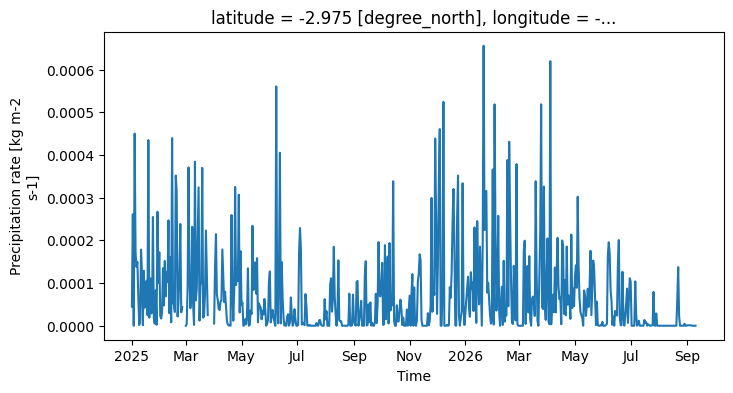

In [3]:
(
    ds["precipitation_surface"]
    .sel(latitude=-3, longitude=-60, method="nearest")
    .sel(time=slice("2025", "2026"))
    .plot(size=4, aspect=2)
)